# 04 · SODAs — discovering the full Differential-Algebraic system

The Michaelis–Menten mechanism

$$E + S \;\underset{k_r}{\overset{k}{\rightleftharpoons}}\; ES \;\xrightarrow{k_{cat}}\; E + P$$

is, under quasi-steady state, a **DAE**: differential laws for the dynamic species *plus*
algebraic constraints linking all four. With $k=k_r=k_{cat}=1$ and total enzyme $E_0=1$, the
**true system** is

$$
\textbf{differential:}\quad \dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES] \\
\textbf{algebraic:}\quad [E]+[ES]=1 \;\;(\text{enzyme conservation}), \qquad
[S][E]=2\,[ES] \;\;(\text{QSSA / steady state}).
$$

**SODAs** (Jayadharan et al., *Proc. R. Soc. A* 2026) discovers this exactly the way the
reference **`DaeFinder`** walkthrough does, in five stages:

1. **discover the conservation law** — *without knowing it in advance*: `AlgModelFinder`
   regresses every variable on the others and ranks the candidates by $R^2$;
2. **refine** the candidate library — drop every term containing the now-redundant `[E]`;
3. **discover the QSSA** relation by running the *same finder* on the refined library;
4. **refine again** — drop the redundant `[S][ES]` term — and **discover the dynamics**;
5. use an **SVD** of the library to *count* how many independent algebraic relations there are.

Finding the algebraic relations first and using them to shrink the library is what keeps the
recovered model physically structured, where one-shot regression drowns in the redundancy the
constraints create.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data: a Michaelis–Menten enzyme assay (multiple substrate levels)

Like a real enzyme assay, we run the **same enzyme** ($E_0=1$, fixed rates) at **several
initial substrate concentrations** $S_0$. This matters: a *single* trajectory admits many
spurious algebraic relations, but the **true** relations are the ones that hold across **all**
trajectories. The QSSA relation is initial-condition–independent, and enzyme conservation
shares the same $E_0$ — so both become identifiable, while substrate totals (which differ per
run) are correctly *not* flagged as universal.

`smooth_data` fits a spline to each trajectory and returns the smoothed states together with
their time derivatives (`d([S]) /dt`, `d([P]) /dt`); `noise_perc=0` here (clean data).

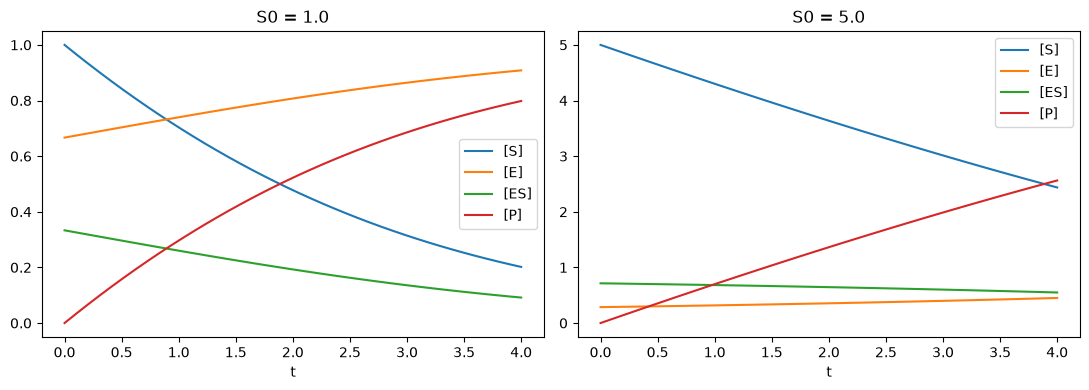

In [3]:
import pandas as pd
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix,
                       AlgModelFinder, sequentialThLin,
                       get_refined_lib, remove_paranth_from_feat)

k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
S0_list = [1.0, 2.0, 3.0, 4.0, 5.0]
species = ["[S]", "[E]", "[ES]", "[P]"]
tg = np.linspace(0, 4, 40)

raw_list, smooth_list = [], []
for S0 in S0_list:
    IC = pd.Series({"S": S0, "P": 0.0, "E": 1.0})
    df = pd.DataFrame(solveMM(IC, k_rates, tg, "demo"), columns=species)
    df["[t]"] = tg
    raw_list.append(df)
    smooth_list.append(smooth_data(df, domain_var="[t]", derr_order=1,
                                   noise_perc=0, eval_points=tg))
smooth_app = pd.concat(smooth_list, ignore_index=True)
state = smooth_app[species]            # smoothed state columns only

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for col, (k, S0) in enumerate([(0, S0_list[0]), (-1, S0_list[-1])]):
    for c in species:
        ax[col].plot(tg, raw_list[k][c], label=c)
    ax[col].set_title(f"S0 = {S0}"); ax[col].legend(); ax[col].set_xlabel("t")
plt.tight_layout(); plt.show()

## Candidate library (degree 2)

Conservation laws are **linear** and the QSSA relation is **quadratic**, so a **degree-2**
polynomial library is the *minimal* one that already contains every fundamental algebraic
relation. We deliberately stop at degree 2: a richer library would also contain **products** of
these relations (e.g. $[S]\cdot$QSSA), which are redundant and make the sparse discovery
*non-unique* — the finder could then return a needlessly high-degree member of the same family.
We drop the constant `1` column (an intercept is fit instead) and register the state variables
as `sympy` symbols so `get_refined_lib` can symbolically drop terms.

In [4]:
import sympy
data_df = state.copy()
# Sympy symbols whose names exactly match the state columns ("[S]","[E]","[ES]","[P]").
S, E, ES, P = sympy.symbols(list(data_df.columns))

lib_full = PolyFeatureMatrix(degree=2).fit_transform(state).drop(["1"], axis=1)
print("library terms (%d):" % lib_full.shape[1], list(lib_full.columns))

library terms (14): ['[S]', '[E]', '[ES]', '[P]', '[S]^2', '[S] [E]', '[S] [ES]', '[S] [P]', '[E]^2', '[E] [ES]', '[E] [P]', '[ES]^2', '[ES] [P]', '[P]^2']


### A discovery helper

`discover_relation` is the heart of SODAs and mirrors the walkthrough: it hands a candidate
library to `AlgModelFinder`, which regresses **every** column on the others, ranks the fits by
$R^2$, and returns the **best** relation — we read off *which* variable ended up on the
left-hand side and *which* terms are active, then refit those exactly with ordinary least
squares. Nothing about the relations is assumed in advance.

In [5]:
import io, contextlib
from sklearn.linear_model import LinearRegression

def discover_relation(finder_lib, refit_lib, fit_intercept, thr=0.1):
    # Discover the strongest algebraic relation in `finder_lib` via AlgModelFinder.
    # Returns (lhs, rhs, ols_model, ranked_r2): the discovered left-hand variable, the
    # active right-hand terms, an exact OLS refit on `refit_lib`, and the R^2 ranking.
    seq = sequentialThLin(model_id="LR", coef_threshold=thr, fit_intercept=fit_intercept)
    finder = AlgModelFinder(custom_model=True, custom_model_ob=seq)
    with contextlib.redirect_stdout(io.StringIO()):      # hush per-column convergence prints
        finder.fit(finder_lib, scale_columns=True)
    ranked_r2 = finder.best_models().loc["r2- metric"].sort_values(ascending=False)
    best = finder.best_models(1)                          # top relation (one column = the LHS)
    lhs = best.columns[0]
    coefs = best[lhs].drop("r2- metric", errors="ignore")
    rhs = list(coefs[coefs.abs() > thr].index)            # active right-hand terms
    ols = LinearRegression(fit_intercept=fit_intercept).fit(refit_lib[rhs], refit_lib[lhs])
    return lhs, rhs, ols, ranked_r2

## Stage 1 — discover the conservation law

We don't know any relation yet, so we let the finder scan the **states** themselves. The two
top-ranked fits ($R^2\approx1$) are `[E]` and `[ES]` — each an affine function of the other —
i.e. the **enzyme conservation** law $[E]+[ES]=E_0$.

In [6]:
lhs, rhs, ols, ranked = discover_relation(state, state, fit_intercept=True)
print("Algebraic relations among the states, ranked by R^2:")
print(ranked.round(3).to_string())

E0 = ols.intercept_
print(f"\nTop relation discovered (LHS = {lhs}):")
print("  %s = %+.3f %s %+.3f   =>   %s + %s = %.3f   (enzyme conservation, true E_0 = 1)"
      % (lhs, ols.coef_[0], rhs[0], E0, lhs, rhs[0], E0))
print("(Substrate totals differ per run, so [S],[P] carry no universal linear law -- correct.)")

Algebraic relations among the states, ranked by R^2:
[E]     1.000
[ES]    1.000
[S]     0.926
[P]     0.140

Top relation discovered (LHS = [E]):
  [E] = -1.000 [ES] +1.000   =>   [E] + [ES] = 1.000   (enzyme conservation, true E_0 = 1)
(Substrate totals differ per run, so [S],[P] carry no universal linear law -- correct.)


## Stage 2 — refine the library: drop `[E]`

Enzyme conservation makes `[E]` **redundant** ($[E]=E_0-[ES]$). SODAs therefore removes every
library term containing `[E]` with `get_refined_lib`. This both shrinks the search and
**rewrites** the remaining relations in terms of the kept variables.

In [7]:
dropped_E, refined_lib = get_refined_lib({E}, data_df, lib_full, get_dropped_feat=True)
print("dropped %d terms containing [E]:" % len(dropped_E))
print("  ", sorted(map(str, dropped_E)))
print("\nrefined library (%d terms):" % refined_lib.shape[1], list(refined_lib.columns))

dropped 5 terms containing [E]:
   ['[E]', '[E] [ES]', '[E] [P]', '[E]^2', '[S] [E]']

refined library (9 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [ES]', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2']


## Stage 3 — discover the QSSA relation on the refined library

Now we run the **same finder again** on the refined library — still without telling it which
relation to expect. The top-ranked fit ($R^2\approx1$) now puts `[S]` on the left:

$$[S] = 2\,[ES] + [S][ES],$$

which is exactly the steady-state law $[S][E]=2[ES]$ rewritten with $[E]=1-[ES]$. The finder
discovered both the left-hand variable **and** the active terms; we only read them off and
refit for the exact coefficients $(2, 1)$.

In [8]:
lhs, rhs, ols, ranked = discover_relation(refined_lib, lib_full, fit_intercept=False)
print("Relations on the refined library, ranked by R^2 (top 5):")
print(ranked.head(5).round(4).to_string())

print(f"\nTop relation discovered (LHS = {lhs}):")
print("  %s = " % lhs + " + ".join("%.3f %s" % (c, n) for n, c in zip(rhs, ols.coef_))
      + "   (R^2 = %.5f)" % ols.score(lib_full[rhs], lib_full[lhs]))
print("  i.e. the QSSA / steady-state law  [S][E] = 2[ES]  rewritten with [E] = 1 - [ES].")

Relations on the refined library, ranked by R^2 (top 5):
[S]         1.0000
[ES]        1.0000
[S] [ES]    1.0000
[ES]^2      0.9997
[S]^2       0.9993

Top relation discovered (LHS = [S]):
  [S] = 2.000 [ES] + 1.000 [S] [ES]   (R^2 = 1.00000)
  i.e. the QSSA / steady-state law  [S][E] = 2[ES]  rewritten with [E] = 1 - [ES].


## Stage 4 — refine again, then discover the dynamics

The QSSA relation makes `[S][ES]` redundant for the dynamics too. After removing `[E]` **and**
`[S][ES]`, the candidate library no longer hides the differential equations, and a thresholded
fit against the spline-derivatives recovers them cleanly.

In [9]:
dropped2, refined_dyn = get_refined_lib({E, S * ES}, data_df, lib_full, get_dropped_feat=True)
print("refined dynamic library (%d terms):" % refined_dyn.shape[1], list(refined_dyn.columns))
print()
for target, truth in [("d([S]) /dt", "-1.0 [ES]"), ("d([P]) /dt", "+1.0 [ES]")]:
    dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
    with contextlib.redirect_stdout(io.StringIO()):
        dyn.fit(X=refined_dyn, y=smooth_app[target])
    terms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_)
             if abs(c) > 1e-2}
    print(f"{target} = {terms}   (true: {truth})")

refined dynamic library (8 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2']

d([S]) /dt = {'[ES]': -1.0}   (true: -1.0 [ES])
d([P]) /dt = {'[ES]': 1.0}   (true: +1.0 [ES])


## Stage 5 — how many algebraic relations? An SVD view

Every algebraic relation makes the columns of the candidate library **linearly dependent on the
data manifold**, so the library matrix is rank-deficient and its **singular value spectrum has
values that collapse toward zero**. This gives an independent, optimizer-free check on the
algebraic structure: standardize the library, take its singular values, and count how many are
negligible relative to the largest.

Each SODAs **refinement removes the redundancy tied to one discovered relation**, so the
near-zero singular values lift away stage by stage. Here the count falls from several (the full
library is heavily rank-deficient), to exactly **one** after removing the conservation
redundancy (the QSSA is the single relation still left), to **zero** after removing the QSSA
redundancy. Reaching full rank in **two refinement steps confirms two independent algebraic
relations**.

full library                               cols=14  near-zero singular values (<1e-06): 6
after dropping {factors of [E]}            cols= 9  near-zero singular values (<1e-06): 1
after dropping {[E], [S][ES] factors}      cols= 8  near-zero singular values (<1e-06): 0


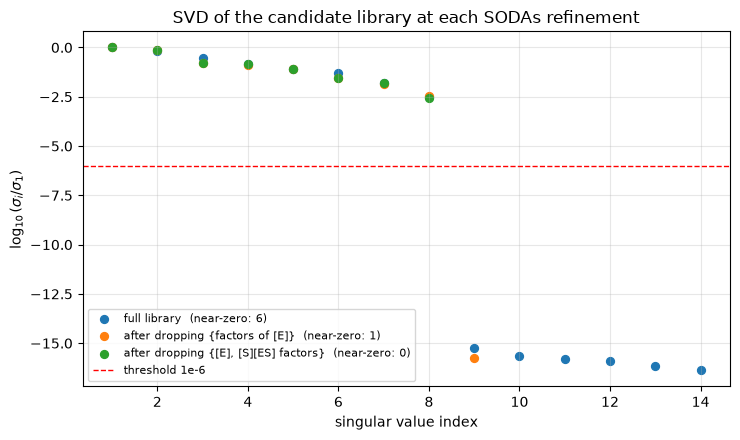


-> two refinements (conservation, then QSSA) drive the near-zero count to 0:
   the data support exactly TWO independent algebraic relations.


In [10]:
from sklearn.preprocessing import StandardScaler

def singular_values(df):
    M = StandardScaler().fit_transform(df)              # zero-mean, unit-variance columns
    return np.linalg.svd(M, compute_uv=False)

stages = [("full library", lib_full),
          ("after dropping {factors of [E]}", refined_lib),
          ("after dropping {[E], [S][ES] factors}", refined_dyn)]

rel_tol = 1e-6
plt.figure(figsize=(7.5, 4.5))
for label, df in stages:
    sv = singular_values(df)
    rel = sv / sv[0]
    n_zero = int((rel < rel_tol).sum())
    plt.scatter(np.arange(1, len(sv) + 1), np.log10(np.clip(rel, 1e-32, None)),
                label=f"{label}  (near-zero: {n_zero})", s=32)
    print(f"{label:42s} cols={df.shape[1]:2d}  near-zero singular values (<{rel_tol:g}): {n_zero}")
plt.axhline(np.log10(rel_tol), color="r", ls="--", lw=1, label=f"threshold 1e{int(np.log10(rel_tol))}")
plt.xlabel("singular value index")
plt.ylabel(r"$\log_{10}(\sigma_i / \sigma_1)$")
plt.title("SVD of the candidate library at each SODAs refinement")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n-> two refinements (conservation, then QSSA) drive the near-zero count to 0:")
print("   the data support exactly TWO independent algebraic relations.")

## The full recovered DAE

$$
\boxed{\;\dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES]\;}
\qquad\text{with}\qquad
\boxed{\;[E]+[ES]=1, \qquad [S][E]=2[ES]\;}
$$

Every term matches the ground truth, the relations were **discovered** (not assumed), and the
SVD independently confirms there are two of them. **Consistency check with notebook 03:**
eliminate the algebraic variables — $[E]=1-[ES]$ and $[S][E]=2[ES]$ give $[ES]=S/(2+S)$ — so
$\dot S = -[ES] = -S/(2+S)$, exactly the rational law SINDy-PI found. SODAs recovered the
*structured* DAE; SINDy-PI recovered its *reduced* rational ODE.

**Takeaway.** By discovering the algebraic constraints first and using each one to refine the
library, SODAs untangles the redundancy that constrained (DAE) systems create — recovering the
conservation and steady-state relations *and* the dynamics, with the SVD spectrum as a built-in
check on how many constraints there are. → `05_benchmark_comparison.ipynb`